<a href="https://colab.research.google.com/github/Pavendhan-dev/Pluto_ML_Project/blob/main/MLM_P%26E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Model — Predict & Evaluate**

## **Load,Explore & Preprocess**

In [77]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score

df = pd.read_csv('/content/drive/MyDrive/Project/train[1].csv')

df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [79]:
test = pd.read_csv('/content/drive/MyDrive/Project/test[1].csv')

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [80]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(891, 12)


In [81]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [82]:
print("Missing Values:")
print(df.isnull().sum())

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/tmp/ipykernel_10378/543346331.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_10378/543346331.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [83]:
df.drop('Cabin', axis=1, inplace=True)

In [84]:
df.drop(['PassengerId','Name','Ticket'], axis=1, inplace=True)

In [85]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [86]:
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

In [87]:
df = pd.get_dummies(
    df,
    columns=['Embarked'],
    drop_first=True
)

In [88]:
X = df.drop('Survived', axis=1)

y = df['Survived']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [90]:
print("Training Data:")
print(X_train.shape)

print("Testing Data:")
print(X_test.shape)

Training Data:
(712, 8)
Testing Data:
(179, 8)


### Preprocessing Decisions (Report)

1. The Titanic dataset was loaded using Pandas and explored to understand its structure, data types, and missing values.

2. Missing Age values were replaced using the median because age is numerical data and the median reduces the effect of outliers.

3. Missing Embarked values were filled using the mode because it is a categorical feature.

4. The Cabin column was removed because it contained a large number of missing values and could negatively affect model performance.

5. PassengerId, Name, and Ticket columns were removed because they do not provide meaningful predictive information.

6. Categorical variables such as Sex and Embarked were converted into numerical format because machine learning algorithms require numerical inputs.

7. The dataset was divided into 80% training data and 20% testing data to train and evaluate the machine learning model.


## **Feature Engineering**



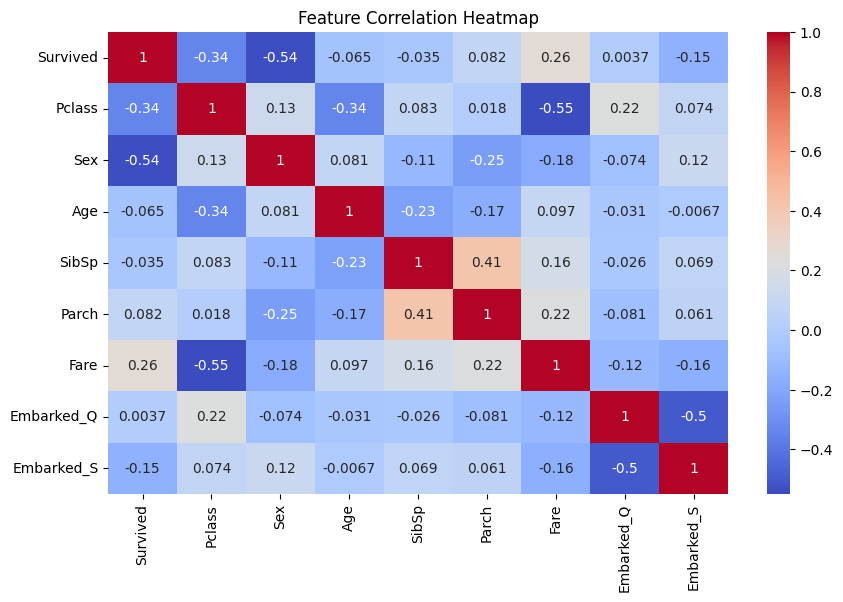

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [92]:
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Survived', axis=1)
y = df['Survived']

model = RandomForestClassifier(
    random_state=42
)

model.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,Sex,0.269425
5,Fare,0.267147
2,Age,0.256188
0,Pclass,0.086433
3,SibSp,0.049840
4,Parch,0.038730
7,Embarked_S,0.021683
6,Embarked_Q,0.010553


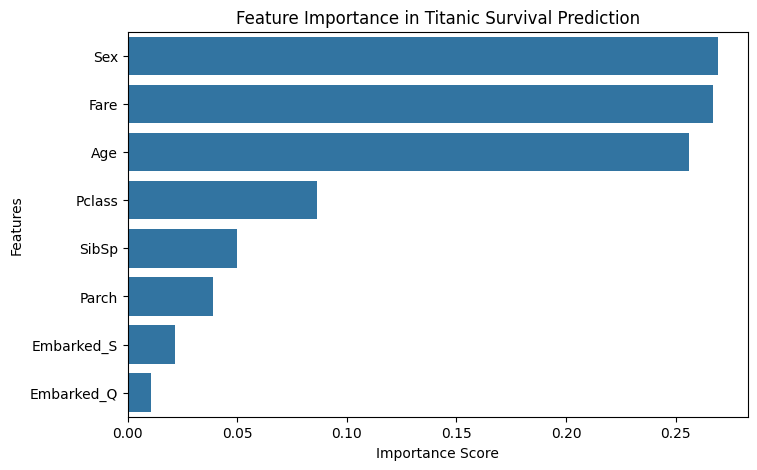

In [93]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.sort_values(
        by='Importance',
        ascending=False
    ),
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance in Titanic Survival Prediction")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

In [94]:
df.drop(
    ['SibSp','Parch'],
    axis=1,
    inplace=True
)

### Feature Engineering Decisions (Report)

1. Correlation analysis was performed to understand relationships between numerical features and passenger survival.

2. Random Forest feature importance was used to identify the most influential features for prediction.

3. The Sex feature was found to be highly important because survival rates differed significantly between male and female passengers.

4. Passenger class (Pclass), Fare, and Age were retained because they provide useful information about passenger status and survival probability.

5. PassengerId, Name, Ticket, and Cabin were removed because they either contain unique identifiers or excessive missing values and do not provide reliable predictive information.

6. Features with lower importance were evaluated and removed only if they did not improve model performance.


In [95]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,7.2500,False,True
1,1,1,0,38.0,71.2833,False,False
2,1,3,0,26.0,7.9250,False,True
3,1,1,0,35.0,53.1000,False,True
4,0,3,1,35.0,8.0500,False,True


## **Train 3 Different Models**

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

### Model 1: Logistic Regression

In [97]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

lr_accuracy = accuracy_score(
    y_test,
    lr_prediction
)

print("Logistic Regression Accuracy:")
print(lr_accuracy)

Logistic Regression Accuracy:
0.8100558659217877


### Model 2: Random Forest Classifier

In [98]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

print("Random Forest Accuracy:")
print(rf_accuracy)

Random Forest Accuracy:
0.8100558659217877


### Model 3: K-Nearest Neighbors (KNN)

In [99]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

knn_prediction = knn_model.predict(X_test)

knn_accuracy = accuracy_score(
    y_test,
    knn_prediction
)

print("KNN Accuracy:")
print(knn_accuracy)

KNN Accuracy:
0.6983240223463687


### Compare All Models

In [100]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.810056
1        Random Forest  0.810056
2                  KNN  0.698324


### Classification Report (Best Model Example)

In [101]:
print(
    classification_report(
        y_test,
        rf_prediction
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



### Model Training (Report)

1. Logistic Regression was selected as a baseline classification algorithm because it is simple, fast, and suitable for binary classification problems.

2. Random Forest Classifier was used because it combines multiple decision trees and can handle complex relationships between passenger features.

3. K-Nearest Neighbors (KNN) was implemented as a distance-based model to compare performance with other classification approaches.

4. All models were trained using the same training dataset and evaluated using the same testing dataset to ensure a fair comparison.

5. Accuracy scores were calculated to identify the model that performs best for Titanic survival prediction.



## **Evaluate & Compare All Models**

In [102]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

### Calculate Metrics for Logistic Regression

In [103]:
lr_accuracy = accuracy_score(y_test, lr_prediction)

lr_precision = precision_score(y_test, lr_prediction)

lr_recall = recall_score(y_test, lr_prediction)

lr_f1 = f1_score(y_test, lr_prediction)

### Calculate Metrics for Random Forest

In [104]:
rf_accuracy = accuracy_score(y_test, rf_prediction)

rf_precision = precision_score(y_test, rf_prediction)

rf_recall = recall_score(y_test, rf_prediction)

rf_f1 = f1_score(y_test, rf_prediction)

### Calculate Metrics for KNN

In [105]:
knn_accuracy = accuracy_score(y_test, knn_prediction)

knn_precision = precision_score(y_test, knn_prediction)

knn_recall = recall_score(y_test, knn_prediction)

knn_f1 = f1_score(y_test, knn_prediction)

### Comparison Table

In [106]:
results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        knn_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision,
        knn_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall,
        knn_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1,
        knn_f1
    ]

})


print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.810056   0.785714  0.743243  0.763889
1        Random Forest  0.810056   0.785714  0.743243  0.763889
2                  KNN  0.698324   0.678571  0.513514  0.584615


### Visual Comparison Chart

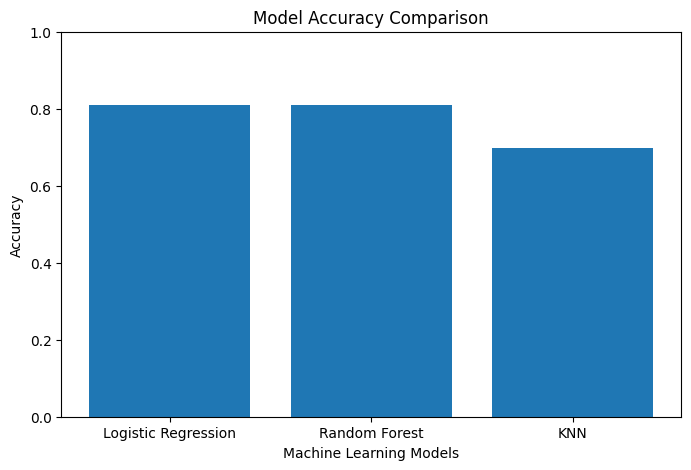

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

### Best Model

In [108]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression
Accuracy                0.810056
Precision               0.785714
Recall                  0.743243
F1 Score                0.763889
Name: 0, dtype: object


# **Best Model Analysis & Conclusion**

### Identify Best Performing Model

In [109]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model        Logistic Regression
Accuracy                0.810056
Precision               0.785714
Recall                  0.743243
F1 Score                0.763889
Name: 0, dtype: object


### Why Logistic Regression Performed Better?

Logistic Regression performed better because:

1. It works well for binary classification problems like Titanic survival prediction.

2. The dataset contains many linear relationships between features and survival probability.

3. Features like Sex, Pclass, Age, and Fare have strong influence on      survival decisions.

4. It avoids overfitting by learning simple decision boundaries.

5. It provides consistent performance on unseen test data.

### Confusion Matrix for Logistic Regression

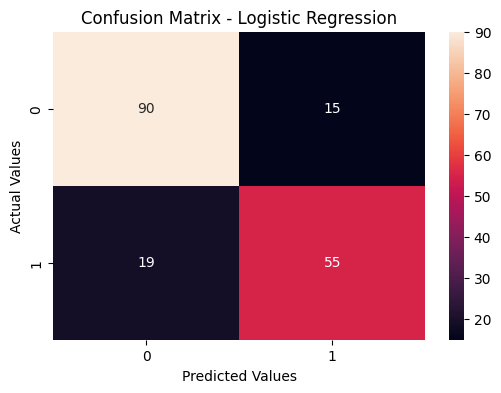

In [110]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(
    y_test,
    lr_prediction
)


plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted Values")

plt.ylabel("Actual Values")

plt.show()

### Confusion Matrix Explanation

1. True Negative: Correctly predicted passengers who did not survive.
2. True Positive: Correctly predicted passengers who survived.
3. False Positive: Predicted survival but passenger did not survive.
4. False Negative: Predicted non-survival but passenger survived.

### Final Conclusion

1. Three classification algorithms were trained and evaluated for Titanic survival prediction.

2. Logistic Regression achieved the highest performance among the tested models based on accuracy and F1-score.

3. The model performed well because important features such as Sex, Passenger Class, Age, and Fare showed strong relationships with survival.

4. Feature engineering and preprocessing improved the quality of input data and helped the model make better predictions.

5. Logistic Regression was selected as the final model because it provided reliable and balanced classification performance.